In [1]:
import os
import sys
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100

In [2]:
# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
# Configuration
class Config:
    # Data
    batch_size = 128
    num_workers = 4
    
    # Model
    model_name = "WideResNet28-10"  # Wide ResNet 28-10
    
    # Training
    epochs = 200
    lr = 0.1
    weight_decay = 5e-4
    momentum = 0.9
    label_smoothing = 0.1
    
    # Augmentation
    use_autoaugment = True
    use_cutmix = True
    use_mixup = True
    cutmix_alpha = 1.0
    mixup_alpha = 1.0
    cutmix_prob = 0.5
    
    # Regularization
    dropout = 0.3
    
    # System
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = 100
    
    # Paths
    data_path = "./data"
    save_path = "./checkpoints"

config = Config()
os.makedirs(config.save_path, exist_ok=True)

print(f"Device: {config.device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## Data Augmentation & Loaders

In [4]:
# CIFAR-100 mean and std
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

# Training transforms with heavy augmentation
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
])

if config.use_autoaugment:
    train_transforms.transforms.append(transforms.AutoAugment(
        policy=transforms.AutoAugmentPolicy.CIFAR10
    ))

train_transforms.transforms.extend([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

# Test transforms
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Load datasets
train_dataset = CIFAR100(root=config.data_path, train=True, 
                         download=True, transform=train_transforms)
test_dataset = CIFAR100(root=config.data_path, train=False, 
                        download=True, transform=test_transforms)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                          shuffle=True, num_workers=config.num_workers,
                          pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                         shuffle=False, num_workers=config.num_workers,
                         pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 169M/169M [00:02<00:00, 69.5MB/s] 


Train samples: 50000
Test samples: 10000


### VISUALIZE SAMPLE IMAGES

In [5]:
def denormalize(tensor, mean, std):
    """Denormalize a tensor image for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

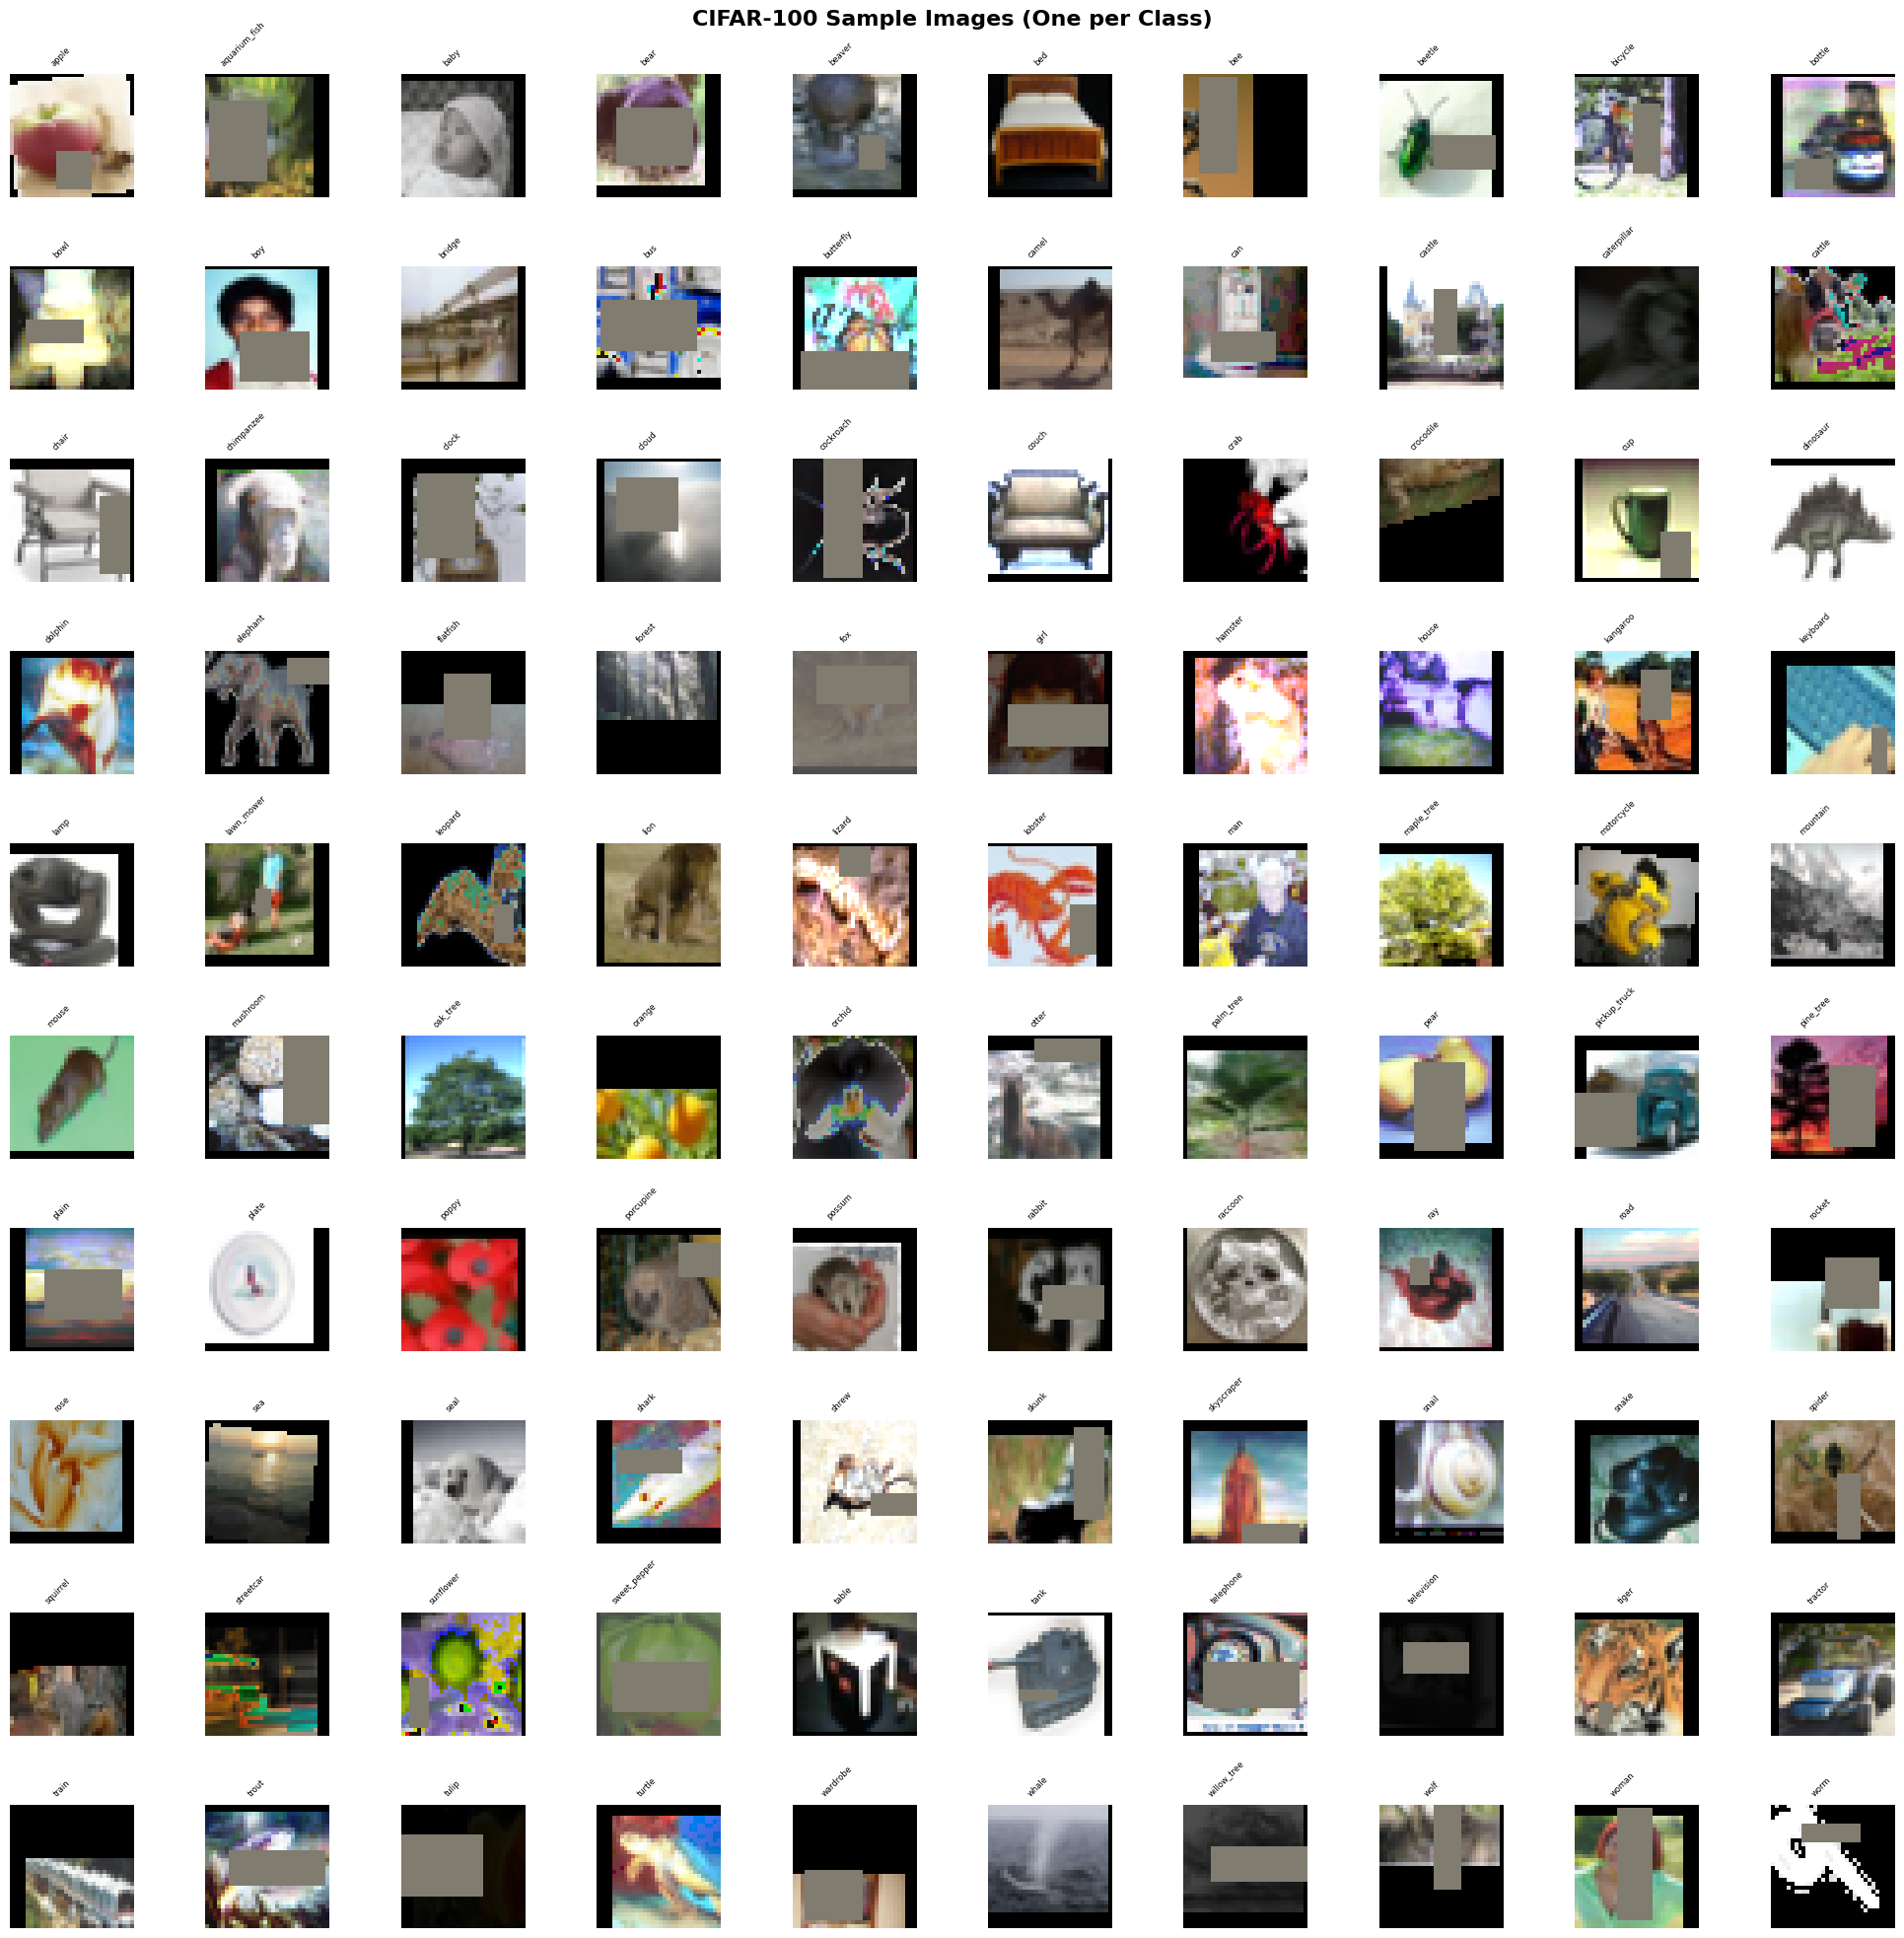

Sample images saved to cifar100_samples.png


In [6]:
# Get class names
classes = train_dataset.classes

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
fig.suptitle('CIFAR-100 Sample Images (One per Class)', fontsize=16, fontweight='bold')

# Get one sample per class
class_samples = {i: [] for i in range(100)}
for img, label in train_dataset:
    if len(class_samples[label]) < 1:
        class_samples[label].append(img)
    if all(len(v) >= 1 for v in class_samples.values()):
        break

for i in range(100):
    row, col = i // 10, i % 10
    img = class_samples[i][0]
    img_denorm = denormalize(img, CIFAR100_MEAN, CIFAR100_STD)
    img_np = img_denorm.permute(1, 2, 0).numpy()
    axes[row, col].imshow(img_np)
    axes[row, col].set_title(classes[i], fontsize=6, rotation=45, ha='right')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('cifar100_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved to cifar100_samples.png")

## MIXUP AND CUTMIX IMPLEMENTATIONS

In [7]:
def mixup_data(x, y, alpha=1.0):
    """Mixup augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    """CutMix augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    
    y_a, y_b = y, y[index]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    
    # Adjust lambda to exactly match pixel ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

def rand_bbox(size, lam):
    """Generate random bounding box for CutMix."""
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    
    return bbx1, bby1, bbx2, bby2

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Criterion for Mixup."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [8]:
class BasicBlock(nn.Module):
    """Wide ResNet Basic Block."""
    def __init__(self, in_planes, out_planes, stride, dropout_rate=0.0):
        super(BasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.dropout_rate = dropout_rate
        self.equalInOut = (in_planes == out_planes)
        self.convShortcut = (not self.equalInOut) and nn.Conv2d(
            in_planes, out_planes, kernel_size=1, stride=stride, 
            padding=0, bias=False) or None

    def forward(self, x):
        if not self.equalInOut:
            x = self.relu1(self.bn1(x))
        else:
            out = self.relu1(self.bn1(x))
        out = self.relu2(self.bn2(self.conv1(out if self.equalInOut else x)))
        if self.dropout_rate > 0:
            out = F.dropout(out, p=self.dropout_rate, training=self.training)
        out = self.conv2(out)
        return torch.add(x if self.equalInOut else self.convShortcut(x), out)

In [9]:
class NetworkBlock(nn.Module):
    """Network block for Wide ResNet."""
    def __init__(self, nb_layers, in_planes, out_planes, block, stride, 
                 dropout_rate=0.0):
        super(NetworkBlock, self).__init__()
        self.layer = self._make_layer(block, in_planes, out_planes, 
                                      nb_layers, stride, dropout_rate)

    def _make_layer(self, block, in_planes, out_planes, nb_layers, stride, 
                    dropout_rate):
        layers = []
        for i in range(int(nb_layers)):
            layers.append(block(i == 0 and in_planes or out_planes, out_planes,
                                i == 0 and stride or 1, dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.layer(x)

In [10]:
class WideResNet(nn.Module):
    """Wide ResNet implementation."""
    def __init__(self, depth, num_classes, widen_factor=1, dropout_rate=0.0):
        super(WideResNet, self).__init__()
        nChannels = [16, 16*widen_factor, 32*widen_factor, 64*widen_factor]
        assert((depth - 4) % 6 == 0)
        n = (depth - 4) / 6
        block = BasicBlock
        
        self.conv1 = nn.Conv2d(3, nChannels[0], kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.block1 = NetworkBlock(n, nChannels[0], nChannels[1], block, 1, 
                                   dropout_rate)
        self.block2 = NetworkBlock(n, nChannels[1], nChannels[2], block, 2, 
                                   dropout_rate)
        self.block3 = NetworkBlock(n, nChannels[2], nChannels[3], block, 2, 
                                   dropout_rate)
        self.bn1 = nn.BatchNorm2d(nChannels[3])
        self.relu = nn.ReLU(inplace=True)
        self.fc = nn.Linear(nChannels[3], num_classes)
        self.nChannels = nChannels[3]
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', 
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.bias.data.zero_()

    def forward(self, x):
        out = self.conv1(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.relu(self.bn1(out))
        out = F.avg_pool2d(out, 8)
        out = out.view(-1, self.nChannels)
        return self.fc(out)


In [11]:
def create_model():
    """Create the model."""
    # Wide ResNet 28-10: depth=28, widen_factor=10
    # This gives ~36.5M parameters
    model = WideResNet(depth=28, num_classes=config.num_classes, 
                       widen_factor=10, dropout_rate=config.dropout)
    return model

In [12]:

model = create_model()
model = model.to(config.device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {config.model_name}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model: WideResNet28-10
Total parameters: 36,536,884
Trainable parameters: 36,536,884


In [13]:
# Label smoothing cross-entropy
criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)

# SGD with Nesterov momentum
optimizer = optim.SGD(model.parameters(), lr=config.lr, 
                      momentum=config.momentum, weight_decay=config.weight_decay,
                      nesterov=True)

# Cosine annealing scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min=0)

In [14]:
# Warmup scheduler
class WarmupScheduler:
    def __init__(self, optimizer, warmup_epochs, base_scheduler):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.base_scheduler = base_scheduler
        self.current_epoch = 0
        
    def step(self):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            lr = config.lr * self.current_epoch / self.warmup_epochs
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
        else:
            self.base_scheduler.step()
    
    def get_last_lr(self):
        return [self.optimizer.param_groups[0]['lr']]

In [15]:
scheduler = WarmupScheduler(optimizer, warmup_epochs=5, base_scheduler=scheduler)

print(f"Loss: CrossEntropy with label smoothing={config.label_smoothing}")
print(f"Optimizer: SGD (lr={config.lr}, momentum={config.momentum}, nesterov=True)")
print(f"Weight decay: {config.weight_decay}")
print(f"Scheduler: Warmup(5 epochs) + CosineAnnealing({config.epochs} epochs)")

Loss: CrossEntropy with label smoothing=0.1
Optimizer: SGD (lr=0.1, momentum=0.9, nesterov=True)
Weight decay: 0.0005
Scheduler: Warmup(5 epochs) + CosineAnnealing(200 epochs)


## Training & Evaluation Function

In [16]:
def train_epoch(model, loader, criterion, optimizer, epoch):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(config.device), targets.to(config.device)
        
        # Apply CutMix or Mixup
        r = np.random.rand()
        if r < config.cutmix_prob and config.use_cutmix:
            inputs, targets_a, targets_b, lam = cutmix_data(inputs, targets, 
                                                            config.cutmix_alpha)
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        elif config.use_mixup:
            inputs, targets_a, targets_b, lam = mixup_data(inputs, targets, 
                                                           config.mixup_alpha)
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        
        # For accuracy calculation with mixup/cutmix, use original targets
        if (r < config.cutmix_prob and config.use_cutmix) or config.use_mixup:
            correct += (lam * predicted.eq(targets_a).sum().item() + 
                       (1 - lam) * predicted.eq(targets_b).sum().item())
        else:
            correct += predicted.eq(targets).sum().item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} [{batch_idx}/{len(loader)}] "
                  f"Loss: {loss.item():.4f} "
                  f"Acc: {100.*correct/total:.2f}%")
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    """Evaluate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(config.device), targets.to(config.device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


## training loop

In [17]:
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'lr': []
}

best_acc = 0.0
start_time = time.time()

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(1, config.epochs + 1):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                        optimizer, epoch)
    
    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    
    # Scheduler step
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)
    
    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }, os.path.join(config.save_path, 'best_model.pth'))
        print(f"*** Best model saved with accuracy: {best_acc:.2f}% ***")
    
    # Save checkpoint every 50 epochs
    if epoch % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
        }, os.path.join(config.save_path, f'checkpoint_epoch_{epoch}.pth'))
    
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch}/{config.epochs} - Time: {epoch_time:.1f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")
    print(f"  LR: {current_lr:.6f} | Best: {best_acc:.2f}%")
    print("-" * 60)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/3600:.2f} hours")
print(f"Best test accuracy: {best_acc:.2f}%")


STARTING TRAINING
Epoch 1 [0/390] Loss: 4.5997 Acc: 1.86%
Epoch 1 [100/390] Loss: 4.6082 Acc: 1.77%
Epoch 1 [200/390] Loss: 4.4576 Acc: 2.11%
Epoch 1 [300/390] Loss: 4.4122 Acc: 2.56%
*** Best model saved with accuracy: 7.71% ***

Epoch 1/200 - Time: 247.5s
  Train Loss: 4.5103 | Train Acc: 2.93%
  Test Loss:  4.1261 | Test Acc:  7.71%
  LR: 0.020000 | Best: 7.71%
------------------------------------------------------------
Epoch 2 [0/390] Loss: 4.4362 Acc: 2.76%
Epoch 2 [100/390] Loss: 4.1805 Acc: 5.12%
Epoch 2 [200/390] Loss: 4.4004 Acc: 5.46%
Epoch 2 [300/390] Loss: 4.3878 Acc: 5.51%
*** Best model saved with accuracy: 10.15% ***

Epoch 2/200 - Time: 250.5s
  Train Loss: 4.3502 | Train Acc: 5.58%
  Test Loss:  4.0360 | Test Acc:  10.15%
  LR: 0.040000 | Best: 10.15%
------------------------------------------------------------
Epoch 3 [0/390] Loss: 4.2846 Acc: 8.49%
Epoch 3 [100/390] Loss: 4.5422 Acc: 5.71%
Epoch 3 [200/390] Loss: 4.4022 Acc: 5.92%
Epoch 3 [300/390] Loss: 4.3833 Acc

KeyboardInterrupt: 

## Plot Curves

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CIFAR-100 Training Results', fontsize=16, fontweight='bold')

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[0, 0].plot(history['test_loss'], label='Test Loss', color='red', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
axes[0, 1].plot(history['test_acc'], label='Test Accuracy', color='red', linewidth=2)
axes[0, 1].axhline(y=best_acc, color='green', linestyle='--', 
                   label=f'Best: {best_acc:.2f}%')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate schedule
axes[1, 0].plot(history['lr'], color='purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Accuracy vs Loss scatter
axes[1, 1].scatter(history['test_loss'], history['test_acc'], 
                   c=range(len(history['test_acc'])), cmap='viridis', alpha=0.7)
axes[1, 1].set_xlabel('Test Loss')
axes[1, 1].set_ylabel('Test Accuracy (%)')
axes[1, 1].set_title('Accuracy vs Loss')
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to training_curves.png")

NameError: name 'plt' is not defined

## TEST-TIME AUGMENTATION (TTA) FOR FINAL EVALUATION

In [ ]:
def tta_predict(model, loader, n_augmentations=5):
    """Test-time augmentation prediction."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(config.device)
            batch_size = inputs.size(0)
            
            # Collect predictions from multiple augmentations
            outputs_list = []
            for _ in range(n_augmentations):
                aug_inputs = inputs.clone()
                if _ > 0:
                    if np.random.rand() > 0.5:
                        aug_inputs = torch.flip(aug_inputs, dims=[3])
                outputs = model(aug_inputs)
                outputs_list.append(F.softmax(outputs, dim=1))
            
            # Average predictions
            avg_outputs = torch.stack(outputs_list).mean(dim=0)
            _, predicted = avg_outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy())
    
    accuracy = 100. * np.sum(np.array(all_preds) == np.array(all_targets)) / len(all_targets)
    return accuracy

# Load best model for TTA evaluation
checkpoint = torch.load(os.path.join(config.save_path, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)
print(f"Best single-model accuracy: {best_acc:.2f}%")

# TTA evaluation
print("\nRunning Test-Time Augmentation (TTA)...")
tta_acc = tta_predict(model, test_loader, n_augmentations=5)
print(f"TTA Accuracy (5 augmentations): {tta_acc:.2f}%")

## PER-CLASS ACCURACY ANALYSIS

In [ ]:
def get_per_class_accuracy(model, loader):
    """Get accuracy for each class."""
    model.eval()
    class_correct = np.zeros(100)
    class_total = np.zeros(100)
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(config.device), targets.to(config.device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            for i in range(len(targets)):
                label = targets[i].item()
                class_total[label] += 1
                if predicted[i] == targets[i]:
                    class_correct[label] += 1
    
    class_acc = 100. * class_correct / (class_total + 1e-8)
    return class_acc, class_correct, class_total


In [ ]:
class_acc, class_correct, class_total = get_per_class_accuracy(model, test_loader)

# Plot per-class accuracy
fig, ax = plt.subplots(figsize=(20, 6))
bars = ax.bar(range(100), class_acc, color='steelblue', alpha=0.7)
ax.axhline(y=best_acc, color='red', linestyle='--', label=f'Overall: {best_acc:.1f}%')
ax.set_xlabel('Class Index')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy on CIFAR-100')
ax.set_xticks(range(100))
ax.set_xticklabels([classes[i][:10] for i in range(100)], rotation=90, fontsize=5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Color bars by accuracy
for bar, acc in zip(bars, class_acc):
    if acc < 50:
        bar.set_color('red')
    elif acc > 90:
        bar.set_color('green')

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best and worst classes
sorted_indices = np.argsort(class_acc)
print("\nTop 10 Best Classes:")
for i in range(1, 11):
    idx = sorted_indices[-i]
    print(f"  {classes[idx]:20s}: {class_acc[idx]:.1f}% ({int(class_correct[idx])}/{int(class_total[idx])})")

print("\nTop 10 Worst Classes:")
for i in range(10):
    idx = sorted_indices[i]
    print(f"  {classes[idx]:20s}: {class_acc[idx]:.1f}% ({int(class_correct[idx])}/{int(class_total[idx])})")

## CONFUSION MATRIX (TOP CLASSES)

In [ ]:
def plot_confusion_matrix(model, loader, n_classes=20):
    """Plot confusion matrix for top N classes by sample count."""
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(config.device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy())
    
    cm = confusion_matrix(all_targets, all_preds)
    
    # Plot subset for readability
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm[:n_classes, :n_classes], annot=True, fmt='d', cmap='Blues',
                xticklabels=[classes[i] for i in range(n_classes)],
                yticklabels=[classes[i] for i in range(n_classes)],
                ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix (First {n_classes} Classes)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:

plot_confusion_matrix(model, test_loader, n_classes=20)

print("\n" + "="*60)
print("NOTEBOOK COMPLETE")
print("="*60)
print(f"Best Accuracy: {best_acc:.2f}%")
print(f"TTA Accuracy: {tta_acc:.2f}%")
print("="*60)
